In [1]:
!pip install pandas numpy seaborn matplotlib scikit-learn imblearn xgboost
!brew install libomp

To reinstall 21.1.8, run:
  brew reinstall libomp


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv('datasets/train.csv')
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [5]:
df.shape

(630000, 13)

In [6]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [7]:
df['internet_access'] = (df['internet_access'] == 'yes').astype(int)

In [8]:
df = df.drop(columns = ['id'])
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,0,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,1,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,1,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,1,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,1,9.6,good,self-study,high,easy,100.0


In [9]:
cat_cols = ['gender','course','sleep_quality','study_method','facility_rating','exam_difficulty']
encoders = {}
for cols in cat_cols:
    encoders[cols] = LabelEncoder()
    df[cols] = encoders[cols].fit_transform(df[cols])

In [10]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,0,1,7.91,98.8,0,4.9,0,3,1,0,78.3
1,18,2,6,4.95,94.8,1,4.7,2,4,2,2,46.7
2,20,0,1,4.68,92.6,1,5.8,2,0,0,2,99.0
3,19,1,1,2.00,49.5,1,8.3,0,1,0,2,63.9
4,23,1,5,7.65,86.9,1,9.6,1,4,0,0,100.0


In [ ]:
features = ['age','course','study_hours','class_attendance','internet_access','sleep_hours','sleep_quality','study_method','facility_rating','exam_difficulty']
x = df[features]
y = df['exam_score']

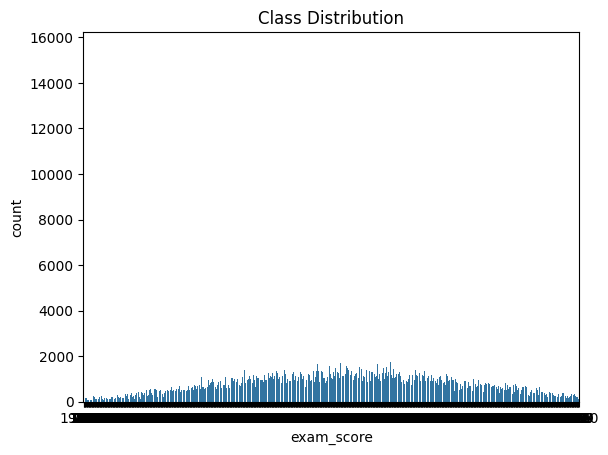

In [12]:
plt.Figure(figsize=(6,4))
sns.countplot(x='exam_score',data=df)
plt.title('Class Distribution')
plt.show()

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42)

In [24]:
xgb_model = xgb.XGBRegressor(
    objetive = 'reg:squarederror',
    learning_rate=0.05,     
    max_depth=6,            
    n_estimators=800,      
    subsample=0.8,          
    colsample_bytree=0.8,         
    gamma=0,              
    booster='gbtree',    
    tree_method='auto',
    eval_metric = 'rmse'  
)

xgb_model.fit(x_train, y_train)

/Users/shivam/Github uploads/Student_test_scores_prediction/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [10:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "objetive" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabe

In [25]:
y_pred = xgb_model.predict(x_test)

In [ ]:
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

RMSE: 8.7447
MAE: 6.9742
MSE: 76.4694


In [27]:
df_sub = pd.read_csv('datasets/test.csv')
df_sub.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [28]:
df_sub['internet_access'] = (df_sub['internet_access'] == 'yes').astype(int)

In [29]:
for col in cat_cols:
    df_sub[col] = encoders[col].transform(df_sub[col])

In [30]:
df_sub.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,2,3,6.85,65.2,1,5.2,2,1,0,0
1,630001,18,1,6,6.61,45.0,0,9.3,2,0,1,0
2,630002,24,0,2,6.60,98.5,1,6.2,1,1,2,2
3,630003,24,1,6,3.03,66.3,1,5.7,0,2,2,2
4,630004,20,0,2,2.03,42.4,1,9.2,0,0,1,2


In [39]:
features = ['age','course','study_hours','class_attendance','internet_access','sleep_hours','sleep_quality','study_method','facility_rating','exam_difficulty']
x_sub = df_sub[features]

In [40]:
y_pred_test = xgb_model.predict(x_sub)

In [44]:
df_sub['exam_score'] = y_pred_test

req_cols = ['id','exam_score']
test_sub = df_sub[req_cols]

output_filename = 'datasets/submissions.csv'
test_sub.to_csv(output_filename, index=False)

In [45]:
!pip freeze > requirements.txt